In [ ]:
Practical No-5 
Aim:
Data Analytics II
1. Implement logistic regression using Python/R to perform classification on
Social_Network_Ads.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
on the given dataset.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [11]:
dataset = pd.read_csv(r"C:\Users\System21\Desktop\diabetes.csv")


In [12]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [14]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


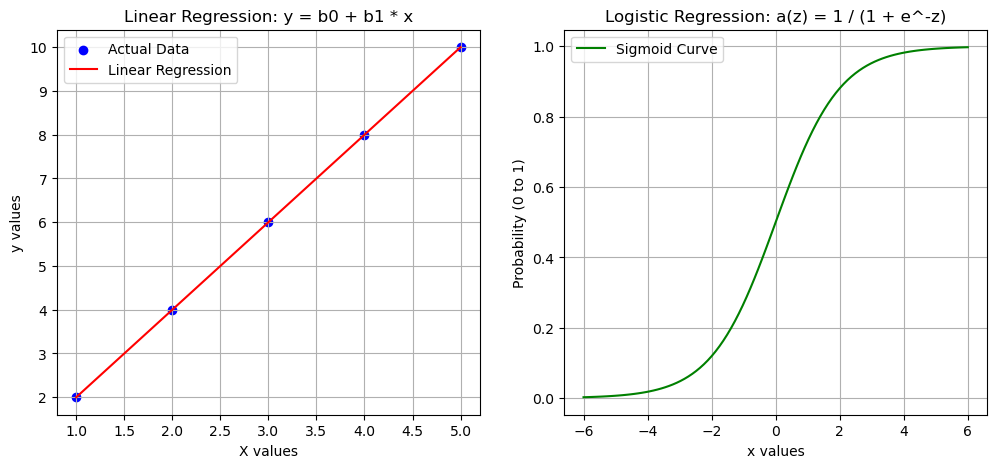

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
def sigmoid(z):
    return 1/(1 + np.exp(-z))
X_linear = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_linear = np.array([2, 4, 6, 8, 10])
linear_model = LinearRegression()
linear_model.fit(X_linear, y_linear)
y_pred_linear = linear_model.predict(X_linear)
X_logistic = np.linspace(-6, 6, 100)
y_logistic = sigmoid(X_logistic)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_linear, y_linear, color='blue', label="Actual Data")
plt.plot(X_linear, y_pred_linear, color='red', label="Linear Regression")
plt.title("Linear Regression: y = b0 + b1 * x")
plt.xlabel("X values")
plt.ylabel("y values")
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(X_logistic, y_logistic, color='green', label="Sigmoid Curve")
plt.title("Logistic Regression: a(z) = 1 / (1 + e^-z)")
plt.xlabel("x values")
plt.ylabel("Probability (0 to 1)")
plt.legend()
plt.grid()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from tabulate import tabulate

# Ignore future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load the dataset
dataset = pd.read_csv("Social_Network_Ads.csv")

# Preview the dataset
print("\nDataset Preview: \n")
print(tabulate(dataset.head(), headers='keys', tablefmt='grid'))

# Prepare features and target
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the logistic regression model
multi_logistic = LogisticRegression(solver='lbfgs')
multi_logistic.fit(X_train, y_train)

# Make predictions on the test set
y_pred_multi = multi_logistic.predict(X_test)
print("\nLogistic Regression Predictions: \n", y_pred_multi)

# Create and display the confusion matrix
cm = confusion_matrix(y_test, y_pred_multi)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
print("\nConfusion Matrix:\n")
print(tabulate(cm_df, headers='keys', tablefmt='grid'))

# Generate and display the classification report
report_df = pd.DataFrame(classification_report(y_test, y_pred_multi, output_dict=True)).transpose()
print("\nClassification Report:\n")
print(tabulate(report_df, headers='keys', tablefmt='grid'))



Dataset Preview: 

+----+-----------+----------+-------+-------------------+-------------+
|    |   User ID | Gender   |   Age |   EstimatedSalary |   Purchased |
+====+===========+==========+=======+===================+=============+
|  0 |  15624510 | Male     |    19 |             19000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  1 |  15810944 | Male     |    35 |             20000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  2 |  15668575 | Female   |    26 |             43000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  3 |  15603246 | Female   |    27 |             57000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  4 |  15804002 | Male     |    19 |             76000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+

Logistic Regression Predictions: 
 [0 1 0 1

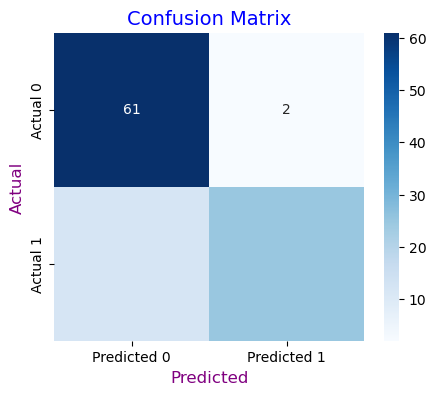

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
warnings.simplefilter(action='ignore', category=FutureWarning)
dataset = pd.read_csv("Social_Network_Ads.csv")
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
logistic_model = LogisticRegression(solver='lbfgs')
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted", fontsize=12, color="purple")
plt.ylabel("Actual", fontsize=12, color="purple")
plt.title("Confusion Matrix", fontsize=14, color="blue")
plt.show()

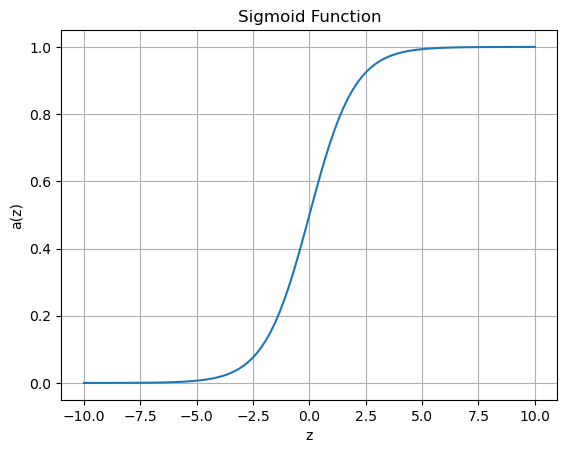

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1/(1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("a(z)")
plt.grid()
plt.show()

In [ ]:
13227 Tanuja Mahajan